In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vijayuv/onlineretail")

print("Path to dataset files:", path)

100%|██████████| 7.20M/7.20M [00:01<00:00, 5.74MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vijayuv/onlineretail/versions/1


In [ ]:
import os
os.listdir(path)

['OnlineRetail.csv']

In [ ]:
df.to_csv('OnlineRetail.csv', index=False)
from google.colab import files
files.download(f"{path}/OnlineRetail.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
file_path = os.path.join(path,
"OnlineRetail.csv")
df=pd.read_csv(file_path,
encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
rows, columns = df.shape

print("Number of rows:",rows)
print("Number of columns:",
columns)

Number of rows: 541909
Number of columns: 8


In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
df.select_dtypes(include=['int64',
'float64']).columns

Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')

In [ ]:
df.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.describe(include='object')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df['Country'].nunique()

38

In [ ]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

# **Dataset Description**

---

The Online Retail dataset contains transaction records from an online retail store. It includes information such as invoice numbers, product descriptions, quantities purchased, invoice dates, unit prices, customer IDs, and the countries where customers are located. The dataset can be used to analyze customer purchasing behavior, sales performance, and product trends.

**DATASET FINDINGS**

---

* The dataset contains 541,909 rows and 8 columns.
* There are 5,268 duplicate records.
* The dataset includes transactions from 38 countries.
* Missing values exist in the Description (1,454) and CustomerID (135,080) columns.
* The United Kingdom appears to be the most frequent country in the dataset.


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


In [ ]:
df = df.dropna(subset=['Description'])



print (df.isnull().sum())

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133583
Country             0
dtype: int64


In [ ]:
df= df.dropna(subset=['CustomerID'])

In [ ]:
df['CustomerID'].isnull().sum()

np.int64(0)

In [ ]:
df['CustomerID'] = df['CustomerID'].fillna('Unknown')


# **MISSING VALUE CLEANING EXPLAINATION**

---

I found 1,454 missing values in Description and removed missing values using dropna().

**Resson**: Product Description are important for product analaysis and missing values could affect the result.

I also found 135,080 in CustomerID and replaced missing CustomerID with 'Unknown'.

**Reason**: This preserves the transaction records while clearly indicating that the CustomerID is unavailable .











In [ ]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


df['Description'] = df['Description'].str.strip().str.upper()


df['Country'] = df['Country'].str.strip()


df.columns = df.columns.str.strip()


print(df.dtypes)
print(df[['InvoiceDate', 'Description', 'Country']].head())

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object
          InvoiceDate                          Description         Country
0 2010-12-01 08:26:00   WHITE HANGING HEART T-LIGHT HOLDER  United Kingdom
1 2010-12-01 08:26:00                  WHITE METAL LANTERN  United Kingdom
2 2010-12-01 08:26:00       CREAM CUPID HEARTS COAT HANGER  United Kingdom
3 2010-12-01 08:26:00  KNITTED UNION FLAG HOT WATER BOTTLE  United Kingdom
4 2010-12-01 08:26:00       RED WOOLLY HOTTIE WHITE HEART.  United Kingdom


In [ ]:
# Check for negative or zero values
print("Negative Quantity count:", (df['Quantity'] < 0).sum())
print("Negative UnitPrice count:", (df['UnitPrice'] < 0).sum())
print("Zero UnitPrice count:", (df['UnitPrice'] == 0).sum())

# Preview a few negative quantity rows to understand them
df[df['Quantity'] < 0].head()

Negative Quantity count: 8872
Negative UnitPrice count: 0
Zero UnitPrice count: 40


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,DISCOUNT,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [ ]:
df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

In [ ]:
print("Negative Quantity count:", (df['Quantity'] < 0).sum())
print("Negative UnitPrice count:", (df['UnitPrice'] < 0).sum())
print("Zero UnitPrice count:", (df['UnitPrice'] == 0).sum())

Negative Quantity count: 0
Negative UnitPrice count: 0
Zero UnitPrice count: 0


# **CLEANING SUMMARY**

---

| Isuues Found  |  Action Taken  |   Reason   |
|---------------|----------------|------------|
| Missing Decription values (1,454 rows) | Removed rows with missng decriptions  | Product decriptions are essential for product-level analysis. |
| Missing Customer ID values (133,583 rows) | Removed rows with missing |Customer ID | Customer ID is required for customer behaviour analysis | .
| Duplicate records (5,268 rows) | Removed duplicate rows | Prevent duplicate transactions from affecting the analysis.   |
| InvoiceDate  format | Converted to the proper datetime format | Enable accurate time-based analysis.  |
| Description column | Removed extra spaces and converted text to uppercase  | Ensure consistency in product names.  |
| Country column | Removed leading and trailing whitespaces | Standardize country. |
| Column names | Removed unnecessary spaces | Creates consistent and easy- to-use column names. |
| Invalid values | Removed records with negative quantities and UnitPrice to zero | Ensuring only valid sales transactions are included in the analysis.








In [ ]:
# Summary statistics for numericals columns
summary = df[['Quantity','UnitPrice',]].agg(['mean','median','min','max','std'])
print(summary)

df.median(numeric_only=True)

            Quantity    UnitPrice
mean       13.119702     3.125914
median      6.000000     1.950000
min         1.000000     0.001000
max     80995.000000  8142.750000
std       180.492832    22.241836


,0
Quantity,6.00
UnitPrice,1.95
CustomerID,15150.00


In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
# Top 10 countries by revenue
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
print("Top 10 Countries by Revenue:\n", top_countries)

Top 10 Countries by Revenue:
 Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


In [ ]:
#Top best selling products by quantity
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 Best-Selling Product:\n",top_products)

Top 10 Best-Selling Product:
 Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [ ]:
# monthly sales trend
df['Year Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Year Month')['Revenue'].sum()
print("Monthly Sales Trend:\n", monthly_sales)

Monthly Sales Trend:
 Year Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64


In [ ]:
most_purchased = df.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
print("Most Purchased Products (by order frequency):\n", most_purchased)

Most Purchased Products (by order frequency):
 Description
WHITE HANGING HEART T-LIGHT HOLDER    1971
REGENCY CAKESTAND 3 TIER              1703
JUMBO BAG RED RETROSPOT               1600
PARTY BUNTING                         1379
ASSORTED COLOUR BIRD ORNAMENT         1375
LUNCH BAG RED RETROSPOT               1288
SET OF 3 CAKE TINS PANTRY DESIGN      1146
POSTAGE                               1099
LUNCH BAG  BLACK SKULL.               1052
PACK OF 72 RETROSPOT CAKE CASES       1029
Name: InvoiceNo, dtype: int64


In [ ]:
# 5. Top 10 customers by total spend
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers by Revenue:\n", top_customers)

Top 10 Customers by Revenue:
 CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

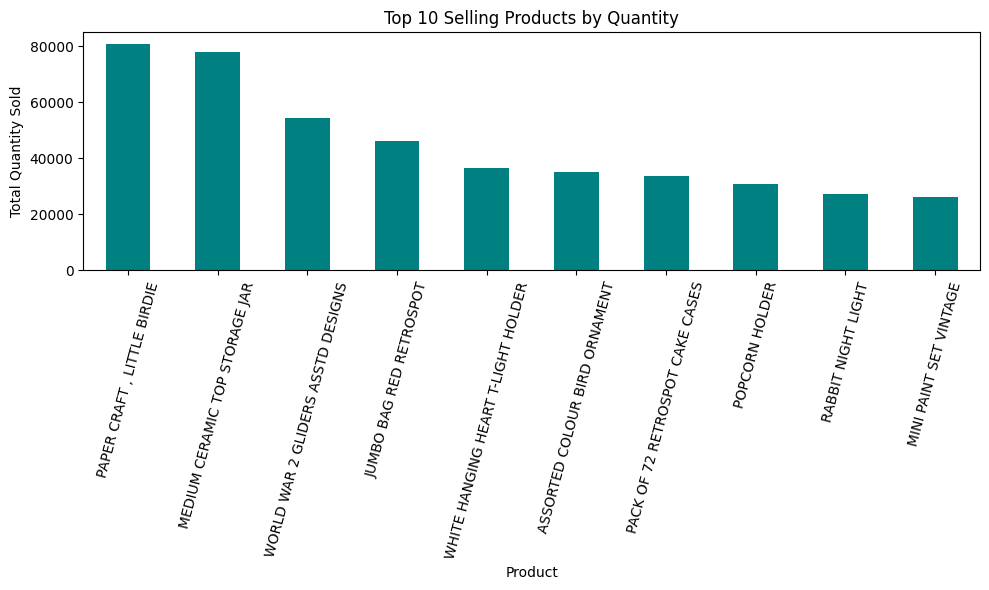

In [ ]:
plt.figure(figsize=(10,6))
top_products.plot(kind='bar', color='teal')
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

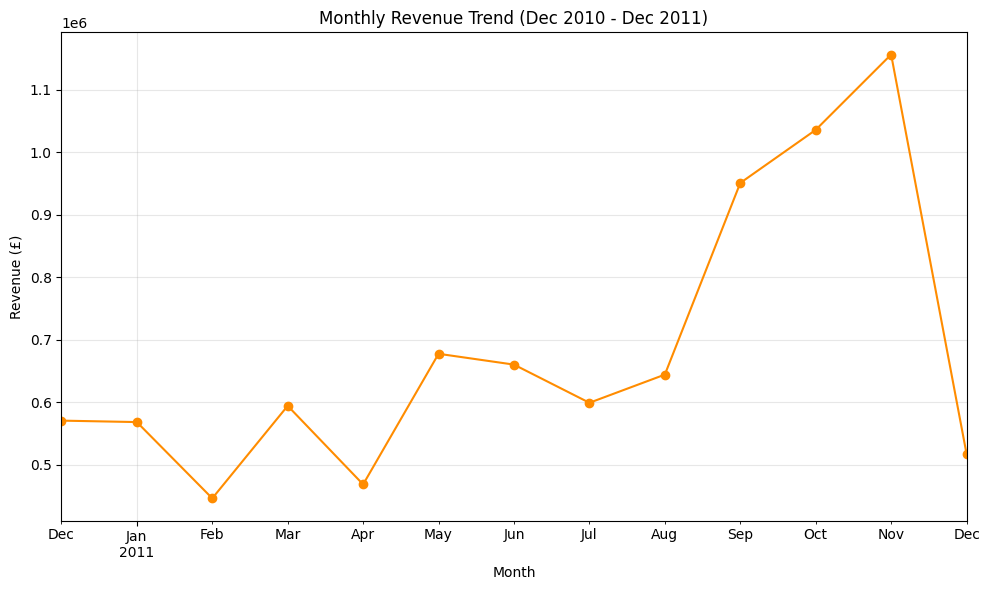

In [ ]:
plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Revenue Trend (Dec 2010 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

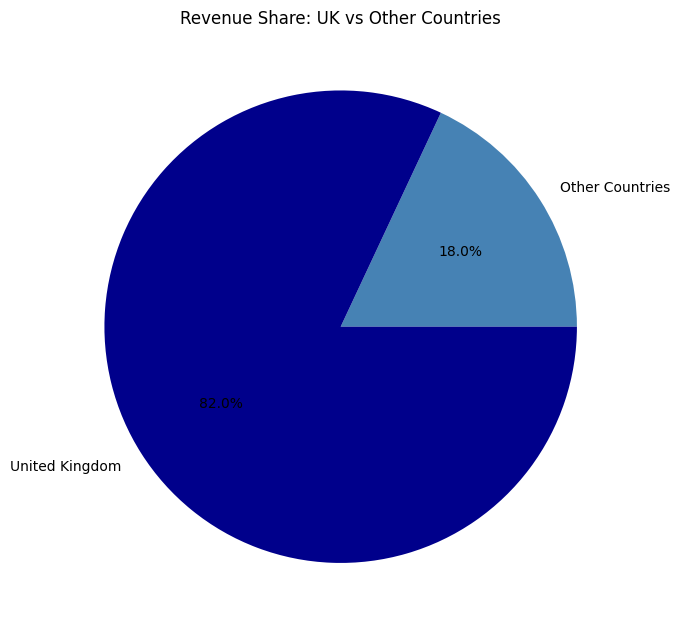

In [ ]:
# Group UK vs Other countries for a cleaner pie chart
df['CountryGroup'] = df['Country'].apply(lambda x: 'United Kingdom' if x == 'United Kingdom' else 'Other Countries')
country_group_revenue = df.groupby('CountryGroup')['Revenue'].sum()

plt.figure(figsize=(7,7))
plt.pie(country_group_revenue, labels=country_group_revenue.index, autopct='%1.1f%%', colors=['steelblue', 'darkblue'])
plt.title('Revenue Share: UK vs Other Countries')
plt.tight_layout()
plt.show()

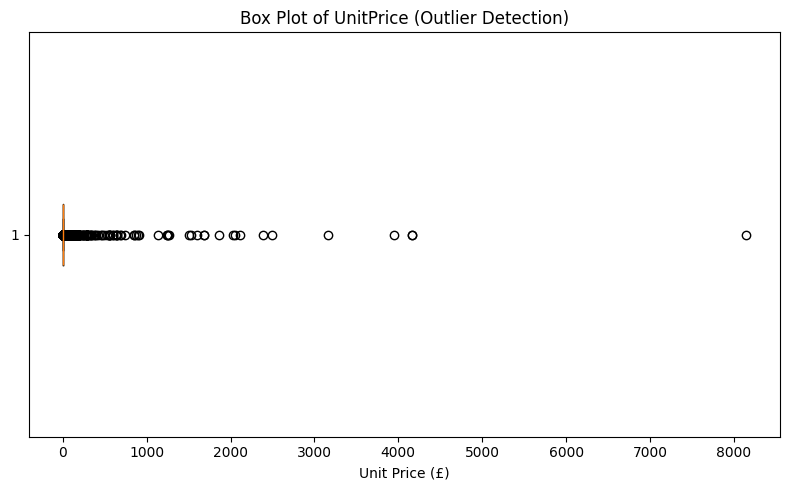

In [ ]:
plt.figure(figsize=(8,5))
plt.boxplot(df['UnitPrice'], vert=False)
plt.title('Box Plot of UnitPrice (Outlier Detection)')
plt.xlabel('Unit Price (£)')
plt.tight_layout()
plt.show()

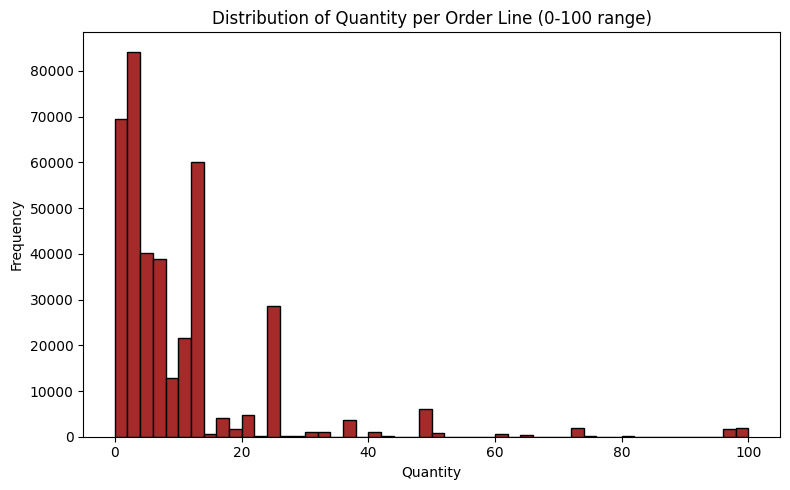

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=50, range=(0,100), color='brown', edgecolor='black')
plt.title('Distribution of Quantity per Order Line (0-100 range)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# **ANALYSIS INSIGHTS**

---

***Sales are heavily seasonal, peaking around the holidays:***

Revenue climbed steadily through the year and peaked sharply in November 2011, consistent with pre-Christmas shopping. (See: Monthly Revenue Trend line chart)

***The business is overwhelmingly UK-based:***

The United Kingdom generated 82% of total revenue, dwarfing every other country the Netherlands, the next highest, brought in a tiny fraction by comparison. (See: Revenue Share pie chart)

***A few products account for a large portion of sales:***

The top-selling products analysis revealed that a small number of items such as "PAPER CRAFT, LITTLE BIRDIE" and "WHITE HANGING HEART T-LIGHT HOLDER" were purchased far more frequently than the rest, indicating strong demand for these items. (See: Top 10 Selling Products bar chart)

***Revenue is concentrated among a small group of top customers:***

The top customer alone (ID 14646) spent over £280,000 far more than typical buyers suggesting a segment of high-value repeat customers worth analyzing separately for loyalty. (See: Top 10 Customers analysis)




# **Online Retail Dataset - Data Cleaning, EDA & Insights Report**

***Project Overview***

---
This project involved cleaning, exploring, and visualizing the Online Retail dataset (541,909 raw transaction records from UK-based e- ecommerce retailer, Dec 2010 - Dec 2011) to improve data quality and generate meaningful business insights. The dataset contains transactional records, including invoice details, product descriptions, quantities, unit prices, customer IDs, invoice dates, and countries.

***Data Cleaning Challenges Encountered***

Several data quality issues were identified during the cleaning process:
* The Description column contained (1,454) missing values, which were removed because product descriptions are essential for product-level analysis  
* The CustomerID column contained (135,080)of missing values. Since these records could not be linked to specific customers, they were fiiled with 'Unknown to preserve product level analysis.
* Duplicate records (5,268) were identified and removed to eliminate repeated transactions.
* The InvoiceDate column was converted from text format to a proper datetime format for time-based analysis.
* Text fields were standardized by converting product descriptions to uppercase and removing extra whitespace from the Country column to ensure consistency.
* The dataset contained negative quantities, representing cancelled or returned orders. These records were excluded from the sales analysis to avoid distorting revenue calculations.
* Cancelled order (8,8772) rows
* No negative unit prices were found, while 40 records had a unit price of zero, which may represent promotional items or free samples.

**final cleaned dataset**:392,692


***Key Exploratory Data Analysis (EDA) Findings***

---
Exploratory Data Analysis revealed several important patterns in the dataset:

* *Seasonality:* Revenue rose steadily through the year, peaking sharply in
  November 2011 (£1.5M), consistent with pre-holiday shopping demand.
* Geographic concentration:* The United Kingdom generated 82% of total revenue, with all other countries combined accounting for only 18%.
* Bestsellers dominate:* A small set of products - "PAPER CRAFT, LITTLE BIRDIE"
  and "WHITE HANGING HEART T-LIGHT HOLDER" among them consistently ranked at the top in both quantity sold and order frequency.
* Customer concentration:* The top customer (ID 14646) alone generated over
  £280,000 in revenue, far exceeding typical spend, pointing to a wholesale or
  high-value business buyer.

***Top Insights***

---
Based on the cleaning, analysis, and visualizations, the following insights were obtained:
* The United Kingdom is the dominant revenue-generating country and represents the company's strongest customer base.
* A few best-selling products contribute significantly to overall sales and should remain a focus for inventory planning and marketing.
* Sales trends vary by month, highlighting the importance of planning for seasonal demand.
* Revenue is concentrated among a small group of top customers, suggesting
value in identifying and retaining high-spend repeat buyers separately from
typical shoppers.

***Conclusion***

---
The data cleaning process improved the quality and consistency of the dataset, making it suitable for analysis. Exploratory Data Analysis and visualizations provided valuable insights into customer behaviour, product performance, sales trends, and country-level revenue. These findings can support data-driven decision-making in inventory management, sales strategy, explore growth in underrepresented international markets and develop retention strategies for its top-spending customers and customer relationship management.